In [68]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

## Forma dei dati (Bode modulo)

Le quantità che uso per il fit sono:

- Variabile indipendente:
$$
x = \log_{10} (f)
$$

- Errore su x (trascurato):
$$
\sigma_x = 0
$$

- Variabile dipendente (in dB):
$$
y = 20 \log_{10}\!\left(\frac{V_{out}}{V_{in}}\right)
$$

- Errore su y:
$$
\sigma_y = 20 \frac{\sigma_A}{A \ln 10}
\quad \text{con} \quad
A = \frac{V_{out}}{V_{in}}
$$

---

## Modello fittato

Per un filtro RC passa-basso:

$$
y(f) = -10 \log_{10}\!\left(1 + \left(\frac{f}{f_c}\right)^2 \right)
$$

dove:
- $( f )$ = frequenza
- $( f_c )$ = frequenza di taglio (parametro del fit)

---

## Parametro fisico ricavato

Dalla frequenza di taglio:

$$
RC = \frac{1}{2\pi f_c}
$$

In [69]:
def modello(par, x):
    return -10 * np.log10(1 + ( (x + par[1]) / par[0])**2) + par[2]

param_labels = ["f_c", "x_off", "y_off"]

beta0 = [5.20005 * 10**3, 0, 0]

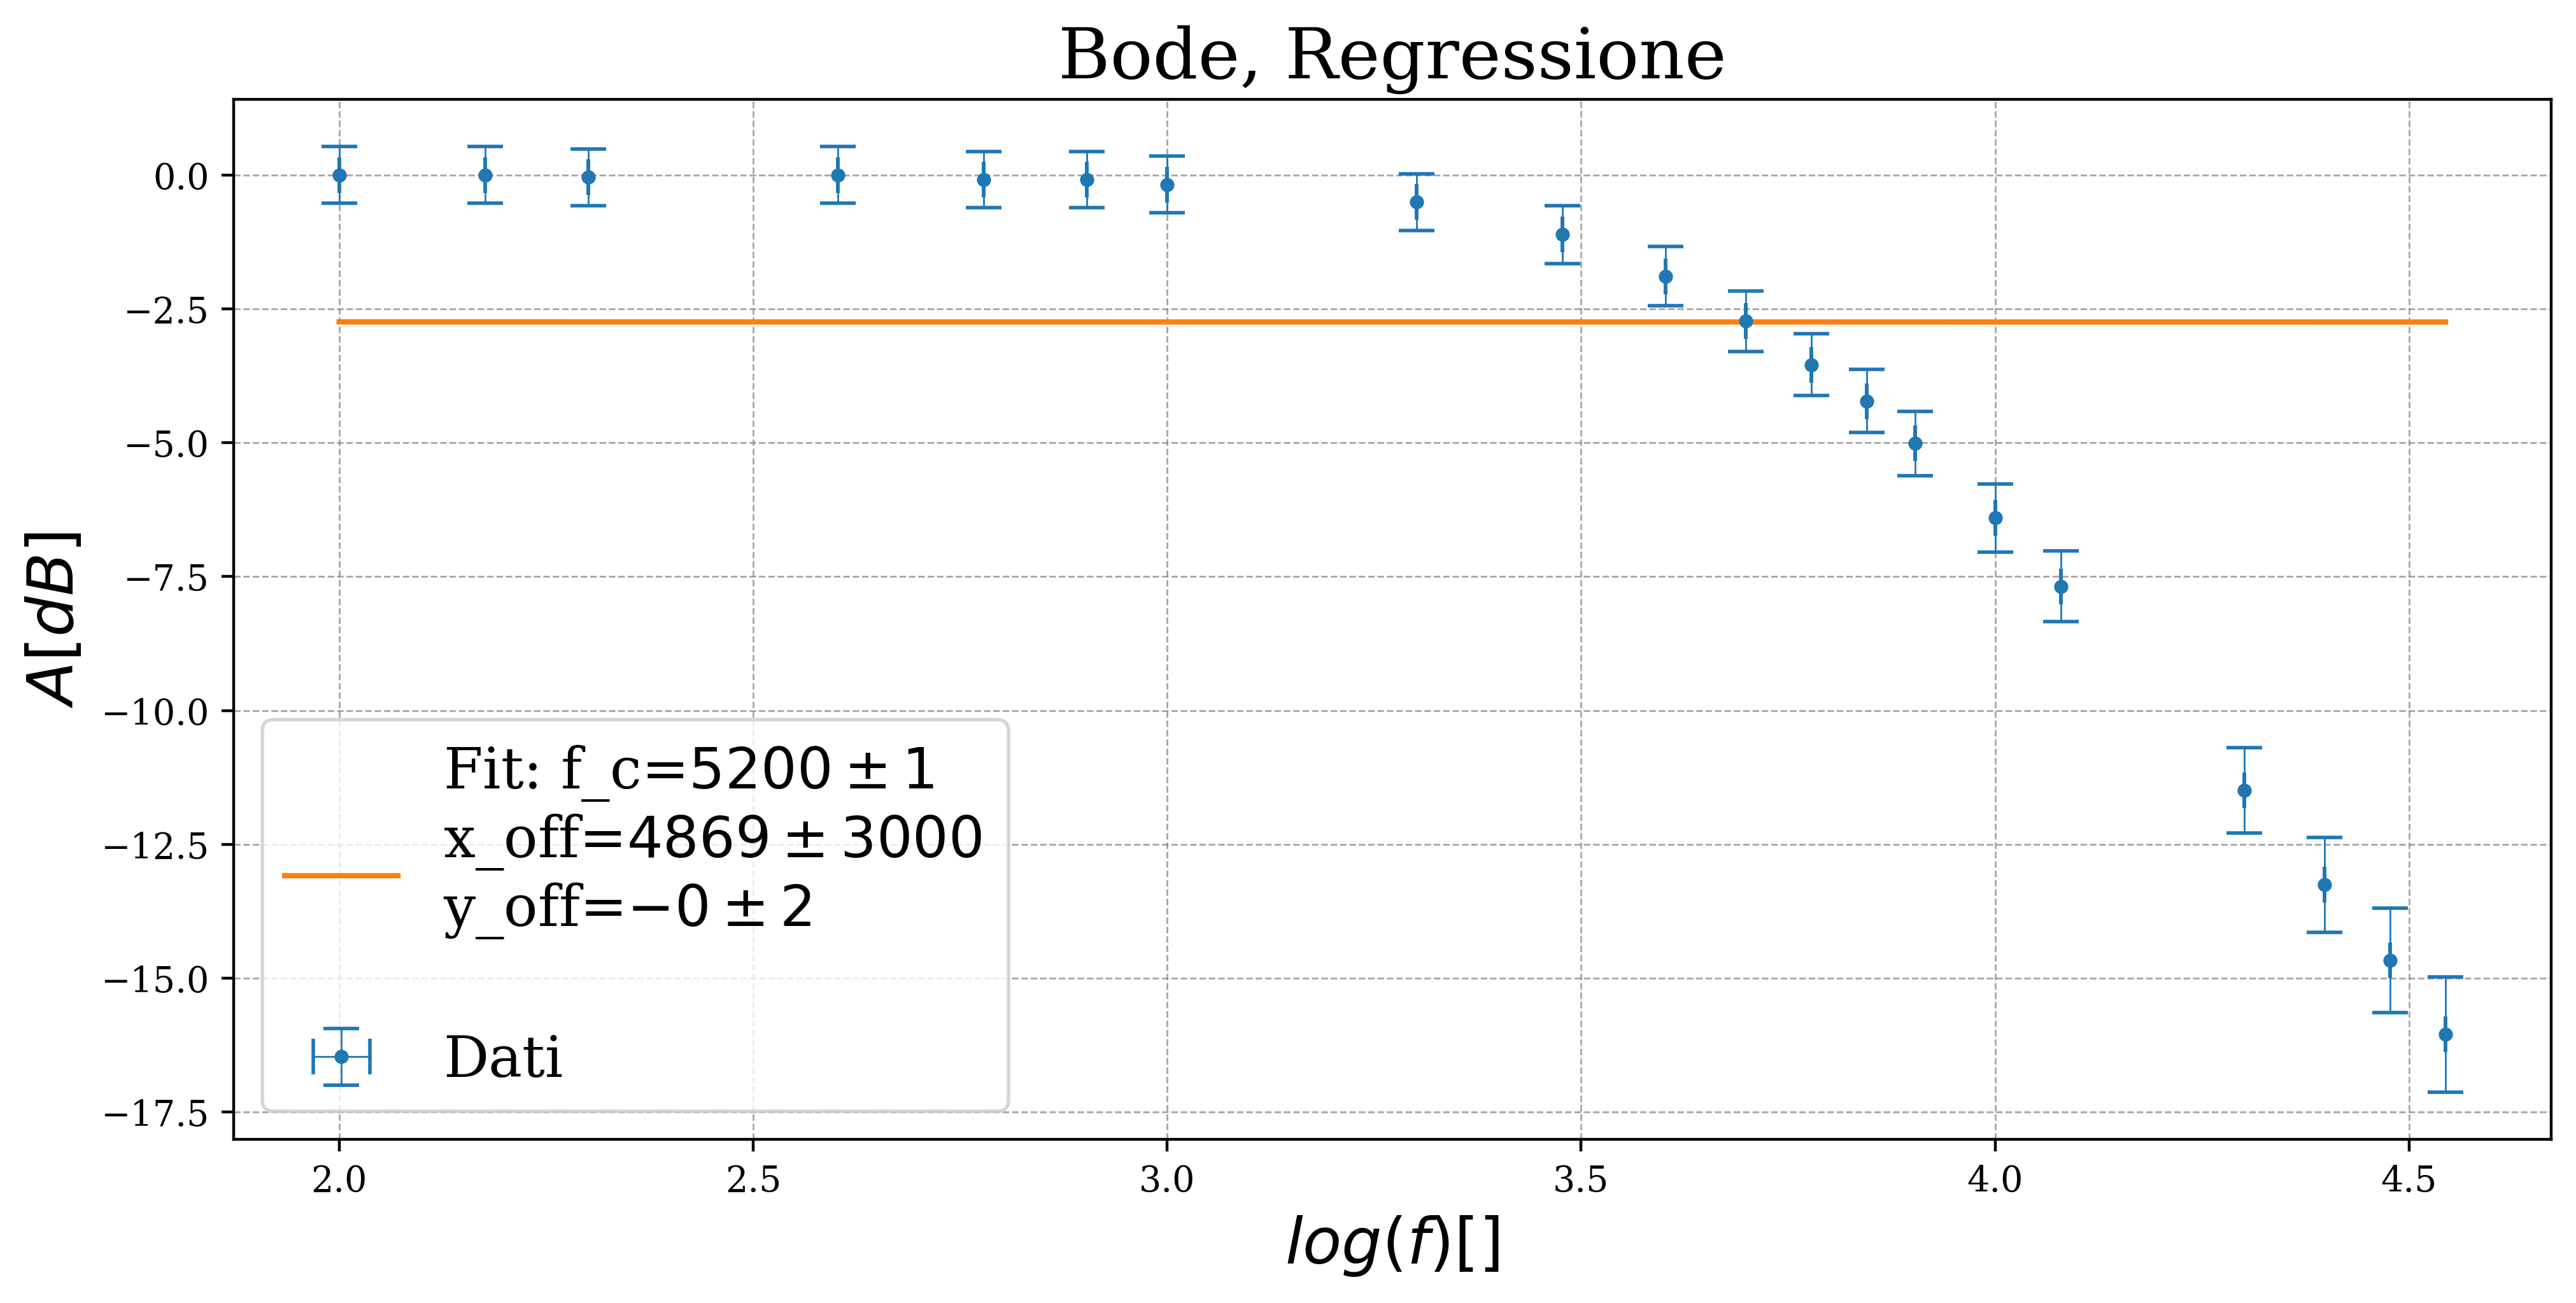

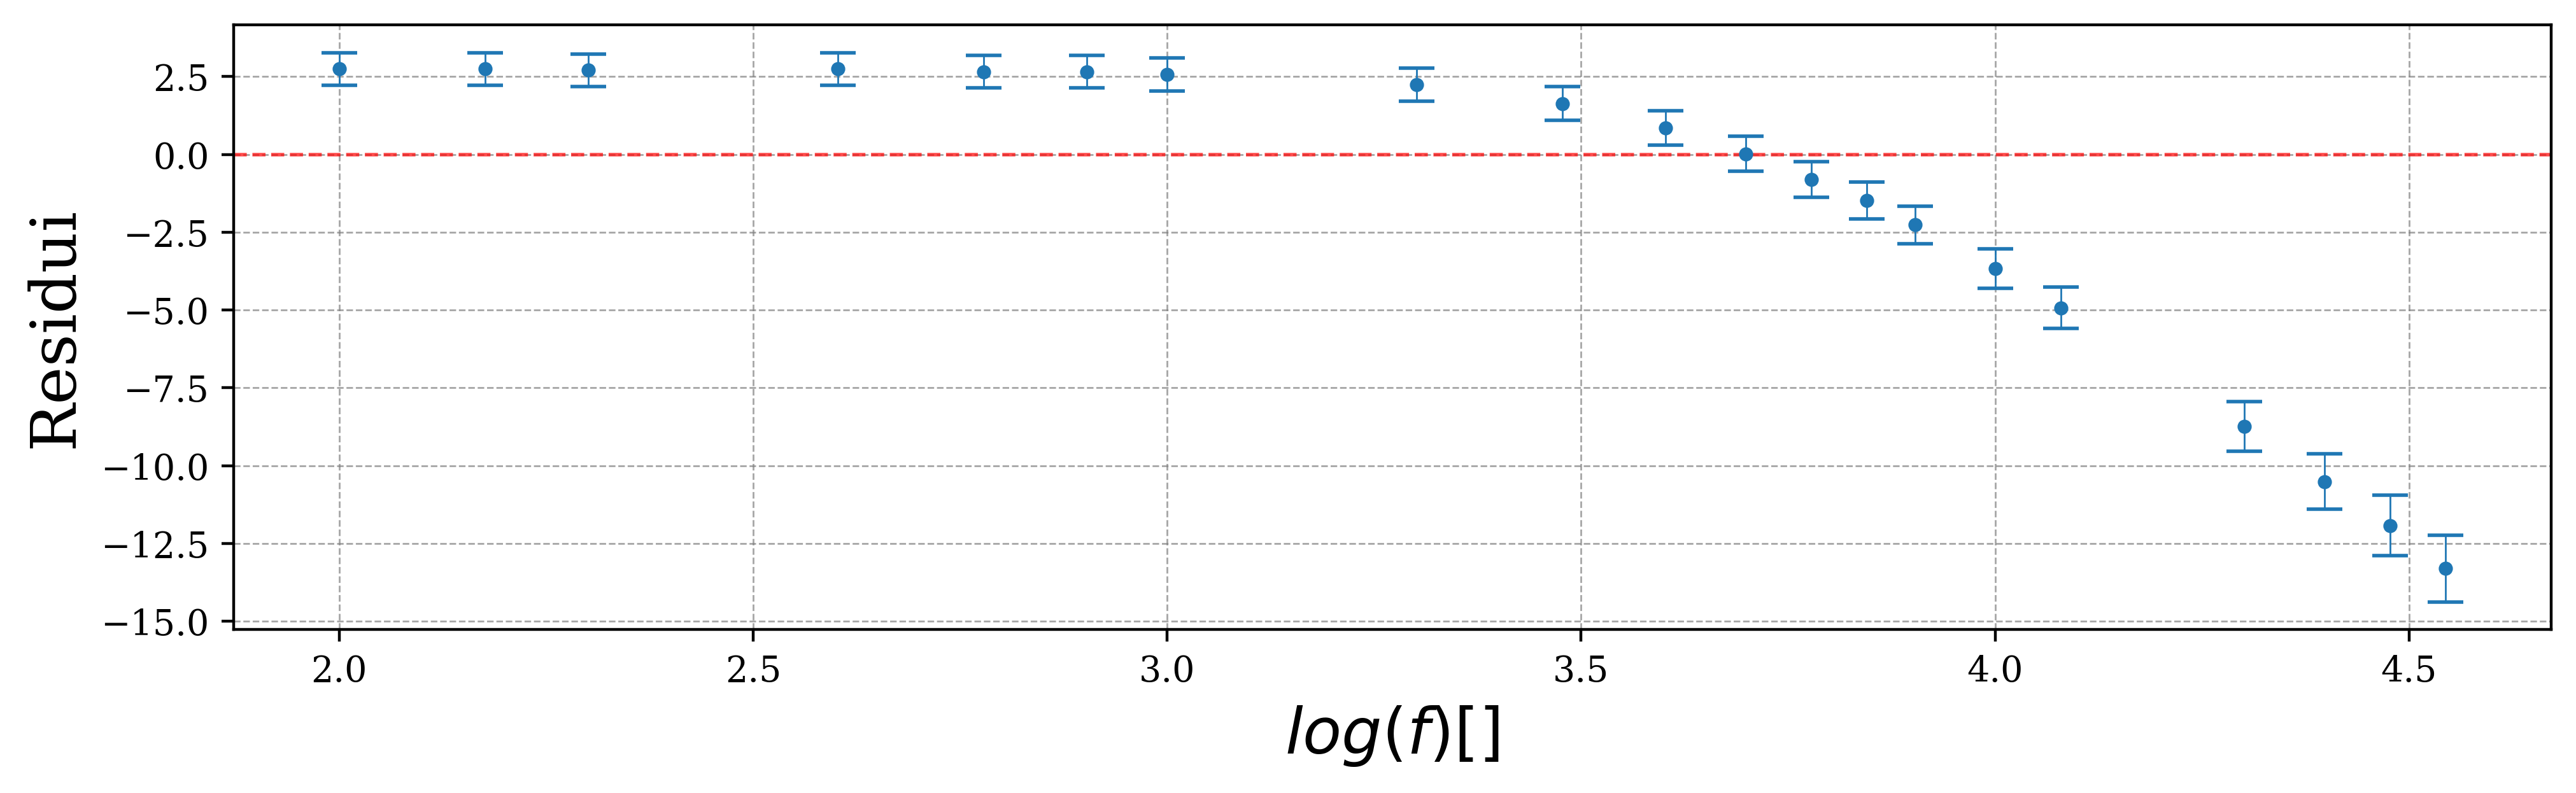

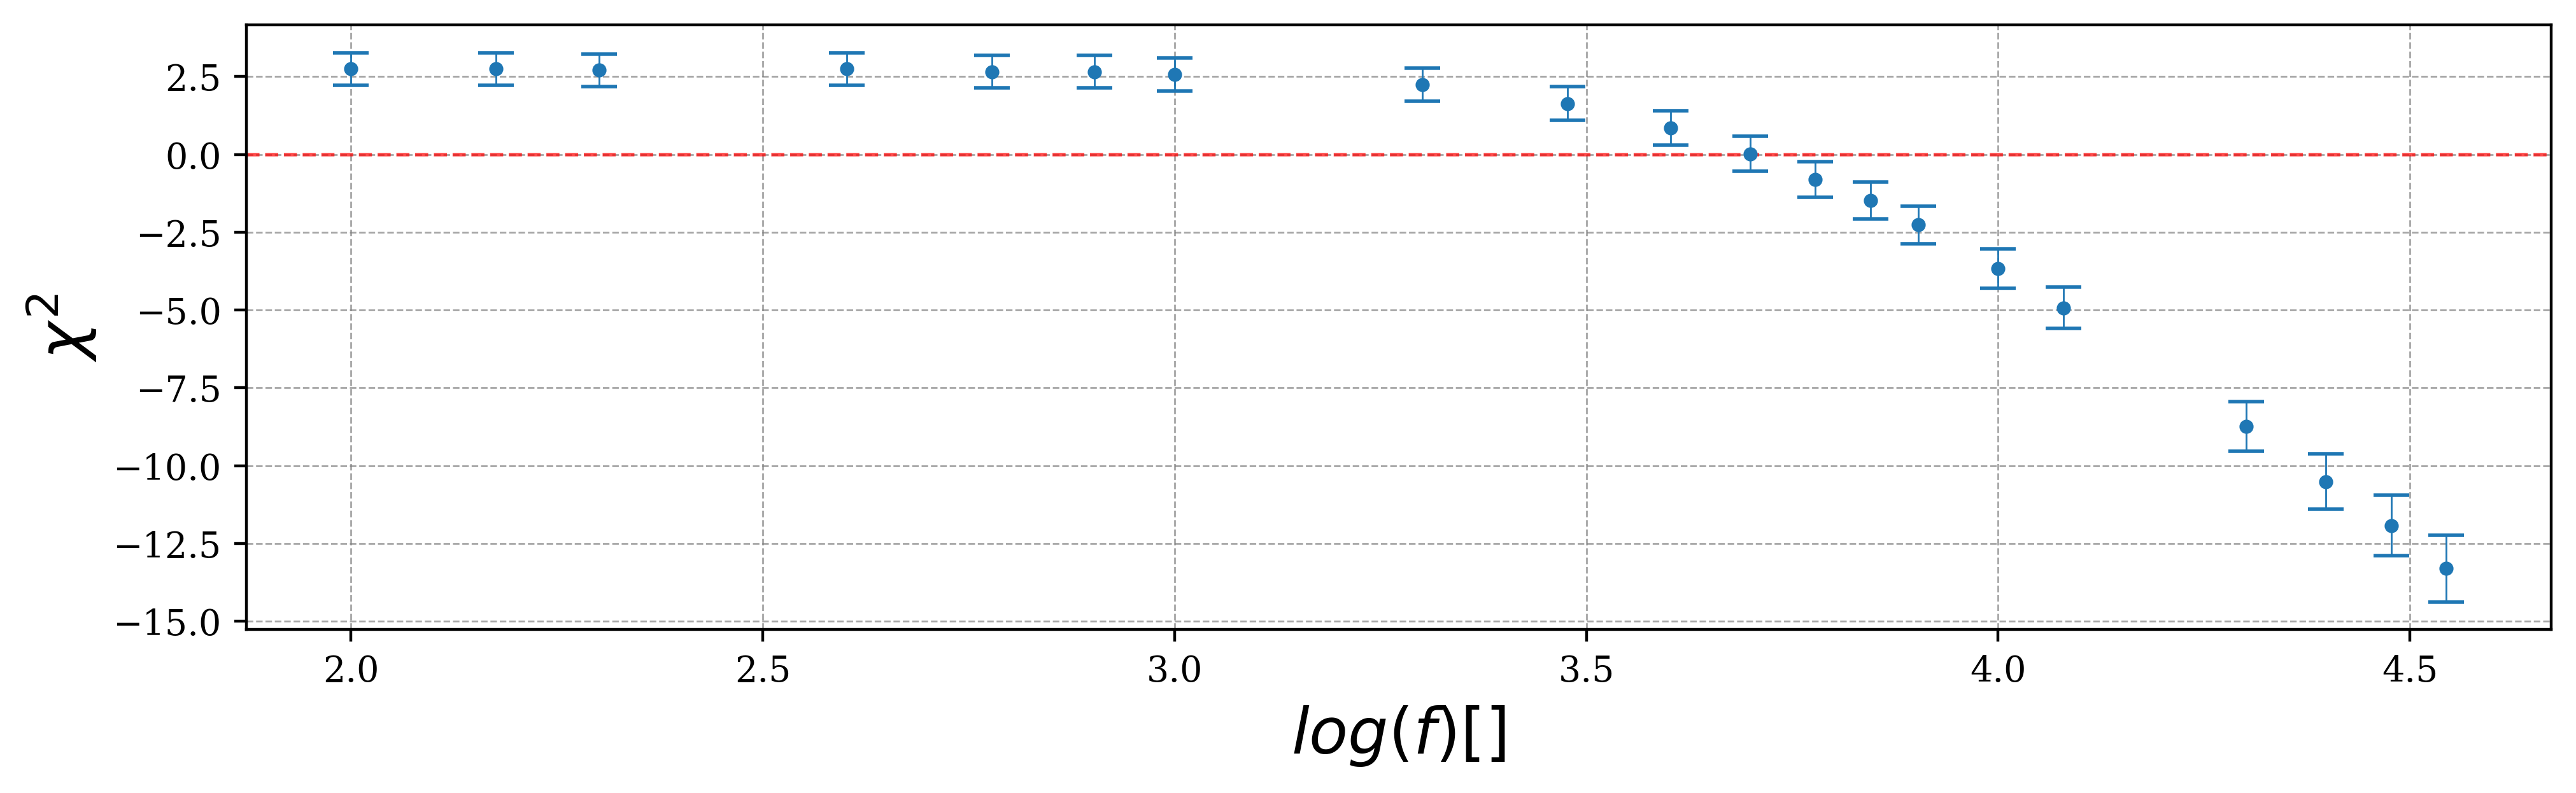

In [70]:
risultati = analizza("bode.json", modello, param_labels, beta0)

In [71]:
print(risultati)

Parametri regressione :
5200.02756396692 ± 1.00104584516535
4868.690898332401 ± 2603.590607504199
-0.009088542224858526 ± 2.262052370641787

Somma residui :
-34.0664
Somma chi quadri e chi ridotto :
-34.0664
-2.0039



In [72]:
risultati_dict = let.ris_fit_to_dict(risultati)
gf.display_dizionario(risultati_dict)
let.esporta_pickle(risultati_dict, filename = f"bode.pkl")

parametri,[ 5.20002756e+03 4.86869090e+03 -9.08854222e-03]
s_parametri,[1.00104585e+00 2.60359061e+03 2.26205237e+00]
res,-34.06642570081852
chi,-34.06642570081852
chi_ridotto,-2.0039073941657954
